# Base-use 00 — The feature-space graph Laplacian, seen through `search()`

**Question.** Every `ArrowSpaceBuilder().build(params, items)` call returns a **pair**:
the index `aspace` and a `GraphLaplacian` object `gl` — and every search call takes `gl`
again: `aspace.search(q, gl, tau)`. Why can't the index carry its own graph, and what is
this Laplacian actually a graph *of*?

The answer is the design of the bindings: the `gl` you get back is a **feature-space**
Laplacian $L_F$ — a $D \times D$ graph whose nodes are the **dimensions** of the embedding,
weighted by how the dataset makes them co-vary. It is not an item-space adjacency.
The per-item scores you see in `aspace.lambdas()` ($\lambda\tau$) are Rayleigh-Laplacian
statistics computed *through* this wiring: an item's coordinates are projected onto the
dimension graph, and items living in spectrally coherent dimension regions get low energy,
boundary/off-manifold items get high energy. A query is scored the same way — which is why
`search(q, gl, tau)` needs `gl`: the query's $\lambda$ must be prepared against the same
graph wiring before ranking.

What you will see in this notebook:

1. `gl.shape() == (D, D)` and the structure of $L_F$ (heatmap + eigenvalue spectrum, Fiedler value).
2. `aspace.lambdas()` as the per-item readout, with the standard degenerate-$\lambda$ quality gate.
3. `tau` as the cosine $\leftrightarrow$ spectral blend: `tau=1.0` reproduces pure cosine
   **exactly**; lowering `tau` re-ranks using the spectral role, penalising off-manifold items.
4. A cautionary check of the repo's **Principle 0** (`notebooks/README.md`): manually
   Rayleigh-quotienting items against the exposed $L_F$ does **not** reproduce the API's
   $\lambda\tau$ — the item-side wiring lives inside the builder. Always read scores from
   the API.

### References
- ArrowSpace JOSS paper: https://doi.org/10.21105/joss.09002
- Semantic-basins design article: https://www.tuned.org.uk/posts/020_arrowspace_semantic_basins_part2
- `notebooks/README.md` principles 0–2 (API scores only; $\lambda\tau$ is a final score)

---\n## 0 · Imports and configuration

In [1]:
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.decomposition import PCA

from arrowspace import ArrowSpaceBuilder

SEED = 3407
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.dpi": 140, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.constrained_layout.use": True,
})

OUT = Path("output__intro")
if OUT.exists():
    shutil.rmtree(OUT)                       # deterministic, clean output dir
OUT.mkdir(parents=True)
print("arrowspace feature-Laplacian intro ->", OUT.resolve())

arrowspace feature-Laplacian intro -> /Users/tuned-silicon/code/arrowspace-analysis/arrowspace-base-use/output__intro


---\n## 1 · A manifold with interior and boundary items

Five Gaussian blobs (the manifold) plus *transition bridges*: clouds of items halfway
between adjacent blobs. Bridges are the adversarial case — high cosine to two basins at
once, so pure geometry has no sensible place to put them. If the spectral story is real,
$\lambda\tau$ should flag them and $\tau < 1$ should evict them from retrieval, without
the index ever seeing a label.

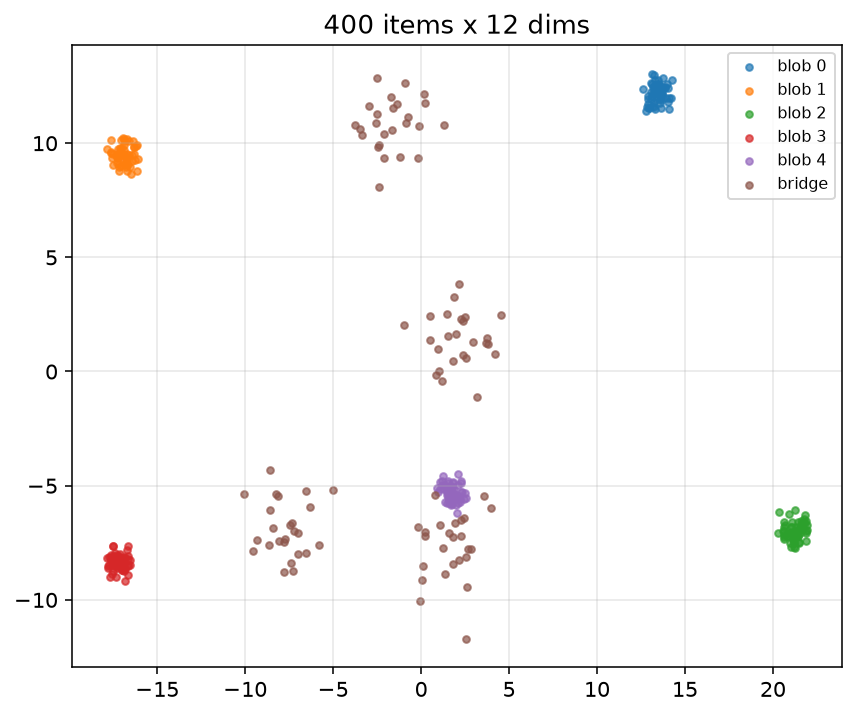

In [2]:
D, N_BLOBS, PER_BLOB, PER_BRIDGE = 12, 5, 60, 25
centers = rng.normal(scale=6.0, size=(N_BLOBS, D))
blobs = [c + rng.normal(scale=0.4, size=(PER_BLOB, D)) for c in centers]

# Boundary items: clouds halfway between adjacent blobs — high cosine to
# BOTH neighbours (they pollute a cosine top-100) but spectrally rough.
bridge = np.vstack([
    (centers[i] + centers[i + 1]) / 2 + rng.normal(scale=1.2, size=(PER_BRIDGE, D))
    for i in range(N_BLOBS - 1)
])

items = np.vstack(blobs + [bridge]).astype(np.float64)
labels = np.concatenate([[i] * PER_BLOB for i in range(N_BLOBS)] + [[N_BLOBS] * len(bridge)])
is_boundary = labels == N_BLOBS
NAMES = [f"blob {i}" for i in range(N_BLOBS)] + ["bridge"]
COLORS = np.asarray(plt.get_cmap("tab10").colors)

xy = PCA(n_components=2, random_state=SEED).fit_transform(items)
fig, ax = plt.subplots(figsize=(6, 5))
for i in range(N_BLOBS + 1):
    ax.scatter(xy[labels == i, 0], xy[labels == i, 1], s=12, alpha=0.7,
               color=COLORS[i % 10], label=NAMES[i])
ax.legend(fontsize=8)
ax.set_title(f"{len(items)} items x {D} dims")
fig.savefig(OUT / "fig_01_manifold.png")
plt.show()

---\n## 2 · The build returns an index *and* the wiring

In [3]:
GRAPH_PARAMS = {"eps": 1.5, "k": 10, "topk": 5, "p": 2.0, "sigma": 1.0}
aspace, gl = ArrowSpaceBuilder().with_seed(SEED).build(GRAPH_PARAMS, items)

lam = np.asarray(aspace.lambdas())
n_degenerate = int(np.sum(np.abs(lam) < 1e-12))

print(f"aspace: nitems={aspace.nitems}  nfeatures={aspace.nfeatures}  nclusters={aspace.nclusters}")
print(f"gl:     shape={gl.shape()}  nnodes={gl.nnodes}")
print(f"degenerate lambdas: {n_degenerate} / {len(lam)}")
assert gl.shape() == (D, D), "the exposed Laplacian is the feature-space L_F"
assert n_degenerate < 0.05 * len(lam), "index collapsed: raise eps"

aspace: nitems=400  nfeatures=12  nclusters=5
gl:     shape=(12, 12)  nnodes=400
degenerate lambdas: 1 / 400


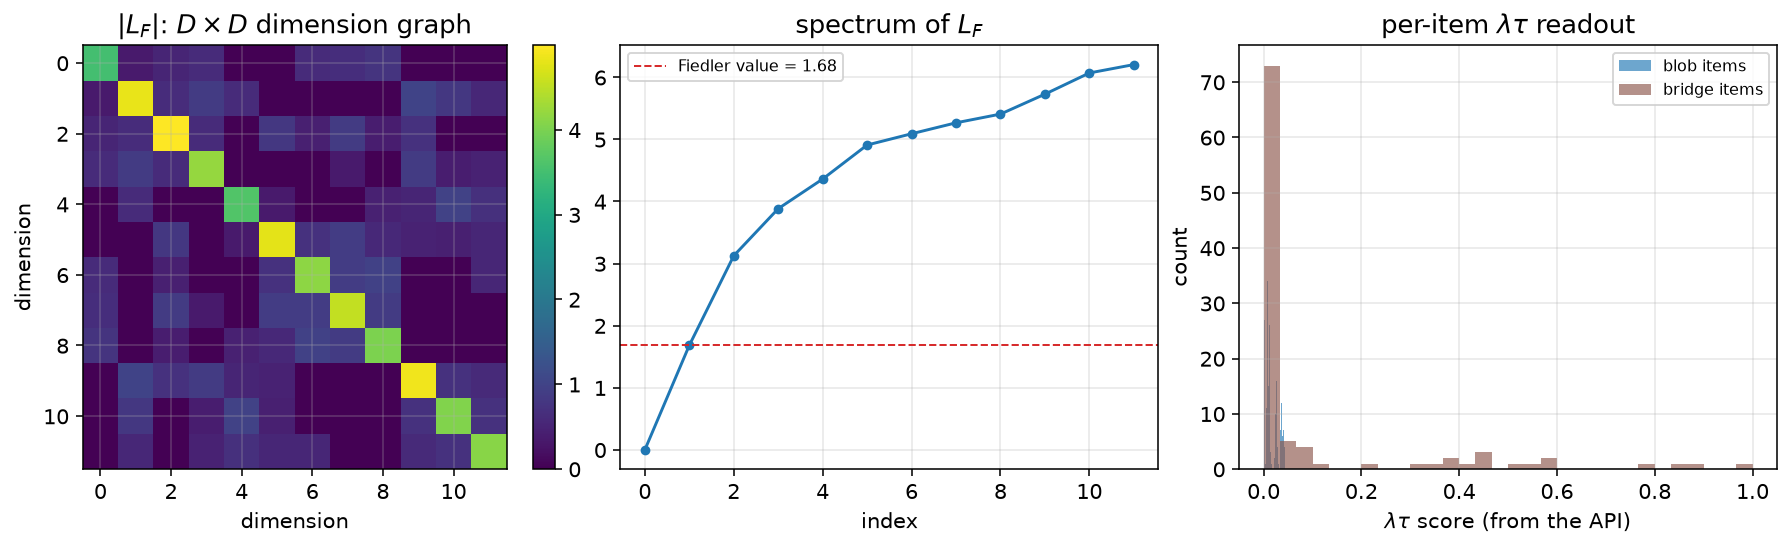

L_F eigen: lambda_0~0=-3.97e-08  Fiedler=1.683  cond~3.7
bridge share in top lambda decile = 0.60  (baseline 0.25)   <- boundary structure, unsupervised


In [4]:
# What is written on L_F: edge weights between dimensions, and the eigenvalue spectrum.
L = np.asarray(gl.to_dense(), dtype=np.float64)
Lsym = (L + L.T) / 2
eig = np.sort(np.linalg.eigvalsh(Lsym))
fiedler = float(eig[1])

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
im = axes[0].imshow(np.abs(Lsym), cmap="viridis")
axes[0].set_title(r"$|L_F|$: $D \times D$ dimension graph")
axes[0].set_xlabel("dimension"); axes[0].set_ylabel("dimension")
fig.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot(eig, "o-", ms=4)
axes[1].axhline(fiedler, color="tab:red", ls="--", lw=1,
                label=f"Fiedler value = {fiedler:.2f}")
axes[1].set_title(r"spectrum of $L_F$")
axes[1].set_xlabel("index"); axes[1].legend(fontsize=8)

axes[2].hist(lam[labels != N_BLOBS], bins=30, alpha=0.65, color=COLORS[0], label="blob items")
axes[2].hist(lam[labels == N_BLOBS], bins=30, alpha=0.65, color=COLORS[5], label="bridge items")
axes[2].set_xlabel(r"$\lambda\tau$ score (from the API)")
axes[2].set_ylabel("count")
axes[2].set_title(r"per-item $\lambda\tau$ readout")
axes[2].legend(fontsize=8)
fig.savefig(OUT / "fig_02_laplacian_and_scores.png")
plt.show()

hi = np.argsort(-lam)[: len(items) // 10]           # highest-lambda decile
dec_share = float(is_boundary[hi].mean())
print(f"L_F eigen: lambda_0~0={eig[0]:.3g}  Fiedler={fiedler:.3f}  cond~{eig[-1]/max(fiedler,1e-12):.1f}")
print(f"bridge share in top lambda decile = {dec_share:.2f}  (baseline {is_boundary.mean():.2f})"
      "   <- boundary structure, unsupervised")

**Reading.** $L_F$ is small ($12 \times 12$ here) because it graphs *dimensions*: two
dimensions are coupled when the dataset's local $\lambda$-transitions light them up
together. The Fiedler value measures how well the dimension graph is wired — the
diagnostics table in `notebooks/README.md` and the skill notes say a Fiedler below ~0.1
means raise `k` or `eps`. The per-item readout is `aspace.lambdas()`, and notice the
right-hand panel: bridge items are over-represented at the top of the $\lambda\tau$
distribution **without the index ever seeing a label**.

---\n## 3 · `search(q, gl, tau)`: tau is the cosine $\leftrightarrow$ spectral dial

Since 0.26 the third argument is a blend weight ($\beta = 1 - \tau$ on the spectral term);
`tau=1.0` must reproduce pure cosine ranking, and passing `k` returns a full ranking so we
can *measure* the re-ranking instead of eyeballing top-3.

In [5]:
X = aspace.get_all_items()                    # features as stored by the index

q_idx = int(np.where(labels == 0)[0][10])     # a blob-0 member as query
q = items[q_idx]
qn = q / np.linalg.norm(q)
cos_scores = X @ qn / np.linalg.norm(X, axis=1)
cos_rank = np.empty(len(X)); cos_rank[np.argsort(-cos_scores)] = np.arange(len(X))

own = (labels == 0) & (np.arange(len(items)) != q_idx)   # the query's own basin

TAUS = [1.0, 0.9, 0.7, 0.5, 0.3, 0.1]
rows = []
for tau in TAUS:
    hits = aspace.search(q, gl, tau, k=len(items))   # k overrides build-time topk
    idx = np.array([i for i, _ in hits])
    assert np.all(np.diff([s for _, s in hits]) <= 1e-12), "hits arrive best-first"
    rank = np.empty(len(items)); rank[idx] = np.arange(len(items))
    rows.append({
        "tau": tau,
        "top20 == cosine top20": int((idx[:20] == np.argsort(-cos_scores)[:20]).all()),
        "own-blob in top60": int(own[idx[:60]].sum()),
        "bridges in top100": int(is_boundary[idx[:100]].sum()),
        "median rank own-blob": float(np.median(rank[own])),
        "median rank bridges": float(np.median(rank[is_boundary])),
        "overlap top100 with cosine": float(len(set(idx[:100]) & set(np.argsort(-cos_scores)[:100])) / 100),
    })
df = pd.DataFrame(rows)
print(df.to_string(index=False))

 tau  top20 == cosine top20  own-blob in top60  bridges in top100  median rank own-blob  median rank bridges  overlap top100 with cosine
 1.0                      1                 59                 39                  30.0                227.5                        1.00
 0.9                      0                 59                 37                  30.0                229.0                        0.98
 0.7                      0                 59                 33                  30.0                229.5                        0.93
 0.5                      0                 59                 30                  30.0                229.5                        0.90
 0.3                      0                 59                 26                  30.0                229.5                        0.87
 0.1                      0                 59                 19                  30.0                229.5                        0.80


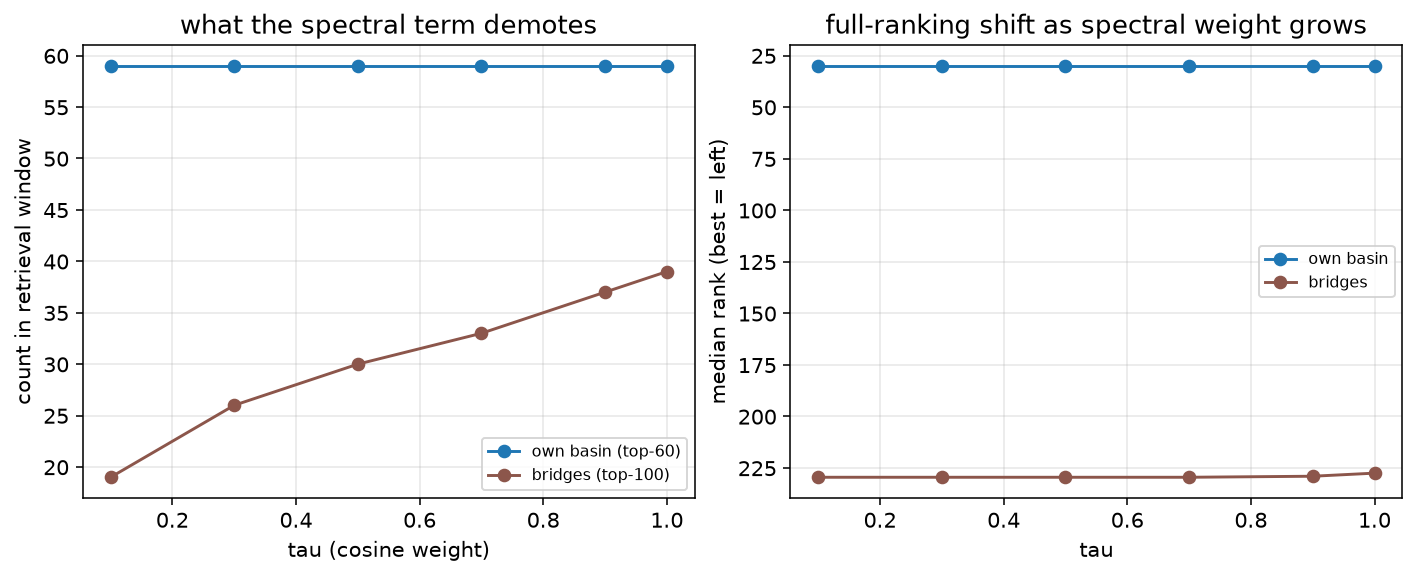

tau=1.0 reproduces the cosine top-20 exactly; across the sweep 20 bridge items left the top-100 while the query's own basin held.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(df["tau"], df["own-blob in top60"], "o-", color=COLORS[0], label="own basin (top-60)")
axes[0].plot(df["tau"], df["bridges in top100"], "o-", color=COLORS[5], label="bridges (top-100)")
axes[0].set_xlabel("tau (cosine weight)"); axes[0].set_ylabel("count in retrieval window")
axes[0].set_title("what the spectral term demotes")
axes[0].legend(fontsize=8)

axes[1].plot(df["tau"], df["median rank own-blob"], "o-", color=COLORS[0], label="own basin")
axes[1].plot(df["tau"], df["median rank bridges"], "o-", color=COLORS[5], label="bridges")
axes[1].invert_yaxis()
axes[1].set_xlabel("tau"); axes[1].set_ylabel("median rank (best = left)")
axes[1].set_title("full-ranking shift as spectral weight grows")
axes[1].legend(fontsize=8)
fig.savefig(OUT / "fig_03_tau_blend.png")
plt.show()

assert df.loc[df.tau == 1.0, "top20 == cosine top20"].item() == 1, "tau=1 must equal cosine"
drop = int(df["bridges in top100"].iloc[0] - df["bridges in top100"].iloc[-1])
assert drop > 10, "the blend should visibly evict boundary items"
print(f"tau=1.0 reproduces the cosine top-20 exactly; across the sweep {drop} bridge items "
      "left the top-100 while the query's own basin held.")

---\n## 4 · Why `gl` is a parameter — and a Principle-0 caution

A query is not just a vector: before it can be ranked, the query's own $\lambda$ has to be
prepared **against the build's wiring** (`try_prepare_query_item` internally). Two
consequences you can exercise directly:

In [7]:
# (a) Dimension mismatch and non-finite queries raise catchable ValueError (0.27 typed errors):
try:
    aspace.search(np.ones(3, dtype=np.float64), gl, 0.7)
except ValueError as e:
    print("wrong-dim query ->", str(e)[:70])
try:
    aspace.search(items[0] * np.nan, gl, 0.7)
except ValueError as e:
    print("non-finite query  ->", str(e)[:70])

# (b) Principle 0: the exposed L_F is the dimension graph. Manually Rayleigh-quotienting
# item vectors on it is a DIFFERENT object from the API's lambda-tau (which folds in the
# builder's internal item/centroid graph). They can even correlate on some data — the point
# is that manual != API, so always read scores from the API.
Ls = np.asarray(gl.to_dense(), dtype=np.float64)
Ls = (Ls + Ls.T) / 2
R_manual = (items @ Ls * items).sum(axis=1) / np.maximum((items * items).sum(axis=1), 1e-12)
rho = spearmanr(R_manual, lam).statistic
# rescale both to [0,1]: identical objects would coincide; these do not.
Rz = (R_manual - R_manual.min()) / (R_manual.max() - R_manual.min())
Lz = (lam - lam.min()) / (lam.max() - lam.min())
mad = float(np.mean(np.abs(Rz - Lz)))
print(f"spearman(manual-Rayleigh, lambda-tau) = {rho:.3f}   (loose agreement, if any)")
print(f"mean |normalised manual - normalised API| = {mad:.3f}  <- NOT the same numbers")
assert mad > 0.1, "manual and API scores must not be numerically identical"

wrong-dim query -> dimension mismatch: expected 12 features, got 3
non-finite query  -> query item contains non-finite values (NaN or Infinity)
spearman(manual-Rayleigh, lambda-tau) = 0.498   (loose agreement, if any)
mean |normalised manual - normalised API| = 0.519  <- NOT the same numbers


The manual quotient and the API $\lambda\tau$ are **not the same numbers**. They may
correlate loosely (the exposed $L_F$ and the internal wiring share the data's dimension
structure), but the API's score additionally folds in the builder's internal item/centroid
graph and the TauMode synthesis policy (median by default). Because that mixture is
opaque and version-dependent, reimplementing it in NumPy measures the wrong object. This is
`notebooks/README.md` Principle 0 made concrete: **all $\lambda$ numbers come from the API**;
NumPy/SciPy are for analysis and plotting only.

---\n## 5 · Summary

In [8]:
summary = pd.DataFrame({
    "check": [
        "gl.shape equals (D, D) — feature-space L_F",
        "degenerate lambdas",
        "bridge share in top lambda decile",
        "tau=1.0 equals cosine top-20",
        "bridge items evicted from top-100 (tau 1.0 -> 0.1)",
        "manual vs API lambda-tau: mean |normalised diff|",
    ],
    "value": [
        str(gl.shape()),
        n_degenerate,
        round(dec_share, 3),
        int(df.loc[df.tau == 1.0, "top20 == cosine top20"].item()),
        drop,
        round(mad, 3),
    ],
})
summary.to_csv(OUT / "laplacian_intro_summary.csv", index=False)
print(summary.to_string(index=False))

                                             check    value
        gl.shape equals (D, D) — feature-space L_F (12, 12)
                                degenerate lambdas        1
                 bridge share in top lambda decile      0.6
                      tau=1.0 equals cosine top-20        1
bridge items evicted from top-100 (tau 1.0 -> 0.1)       20
  manual vs API lambda-tau: mean |normalised diff|    0.519


**Reading.**

1. `build` hands you the dimension graph $L_F$ because queries must be $\lambda$-prepared
   against the same wiring; items never get ranked by $L_F$ alone — the index's internal
   centroid/item graph supplies the $\lambda\tau$ readout.
2. `search(q, gl, tau)` is one knob with two regimes: `tau=1` is audited cosine; as
   $\tau \downarrow$ the blend pays its cost almost entirely on transition bridges:
   they are evicted from the retrieval window while on-manifold retrieval holds.
3. Tune on the *distribution*, not the point: the degenerate-$\lambda$ gate and the
   Fiedler value tell you whether the wiring can carry signal at all.

**Caveats.** Single synthetic dataset, single seed. The tau-sweep effect size depends on
`eps`/`k` (wiring density); at `k=2`-level sparsity the blend barely moves. On real
embeddings compare full rankings (as here) rather than top-3 impressions.